In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For astronomical data
from astropy.table import Table

# Configure visualization
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("🌍 K2 Exoplanet Habitability Classification Pipeline")
print("📊 Libraries loaded successfully!")
print("="*60)

🌍 K2 Exoplanet Habitability Classification Pipeline
📊 Libraries loaded successfully!


# 1. Data Loading and Initial Exploration

Load the K2 dataset and examine its structure for habitability-relevant features.

In [2]:
# Load K2 dataset
print("📂 Loading K2 dataset...\n")
df = pd.read_csv(
    "../Datasets/k2_dataset.csv",
    sep=",",
    comment="#",
    skipinitialspace=True,
    low_memory=False
)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Dataset summary
print("✅ K2 Dataset successfully loaded!\n")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📝 Total features: {df.shape[1]}\n")

# Show column categories
print("🔍 Available Column Categories:")
print(f"  • Identifiers: pl_name, hostname, k2_name, epic_hostname")
print(f"  • Planetary params: pl_orbper, pl_rade, pl_masse, pl_insol, pl_eqt")
print(f"  • Stellar params: st_teff, st_rad, st_mass, st_lum")
print(f"  • Orbital params: pl_orbsmax, pl_orbeccen, pl_orbincl")

print("\n📋 First 3 rows preview:")
df.head(3)

📂 Loading K2 dataset...

✅ K2 Dataset successfully loaded!

📊 Shape: 3992 rows × 295 columns
📝 Total features: 295

🔍 Available Column Categories:
  • Identifiers: pl_name, hostname, k2_name, epic_hostname
  • Planetary params: pl_orbper, pl_rade, pl_masse, pl_insol, pl_eqt
  • Stellar params: st_teff, st_rad, st_mass, st_lum
  • Orbital params: pl_orbsmax, pl_orbeccen, pl_orbincl

📋 First 3 rows preview:


,rowid,pl_name,hostname,pl_letter,k2_name,epic_hostname,epic_candname,hd_name,hip_name,tic_id,...,releasedate,pl_nnotes,k2_campaigns,k2_campaigns_num,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,BD+20 594 b,BD+20 594,b,K2-56 b,EPIC 210848071,EPIC 210848071.01,NaN,NaN,TIC 26123781,...,2018-02-15,1.0,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,BD+20 594 b,BD+20 594,b,K2-56 b,EPIC 210848071,EPIC 210848071.01,NaN,NaN,TIC 26123781,...,2016-07-28,1.0,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,BD+20 594 b,BD+20 594,b,K2-56 b,EPIC 210848071,EPIC 210848071.01,NaN,NaN,TIC 26123781,...,2018-04-26,1.0,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Check original disposition distribution
print("🎯 Original Archive Disposition Distribution:")
if 'disposition' in df.columns:
    print(df['disposition'].value_counts())
    print(f"\nTotal confirmed planets: {(df['disposition'] == 'CONFIRMED').sum()}")
else:
    print("⚠️ 'disposition' column not found - will work with all planets")

print("\n" + "="*60)
print("📊 Data Quality Assessment:")
print("="*60)

# Missing values analysis
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

print(f"Columns with missing values: {(missing_counts > 0).sum()}")
print(f"Columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >90% missing: {(missing_pct > 90).sum()}")

# Data types
print(f"\nNumeric columns: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")

🎯 Original Archive Disposition Distribution:
disposition
CONFIRMED         2308
CANDIDATE         1369
FALSE POSITIVE     293
REFUTED             22
Name: count, dtype: int64

Total confirmed planets: 2308

📊 Data Quality Assessment:
Columns with missing values: 289
Columns with >50% missing: 145
Columns with >90% missing: 77

Numeric columns: 262
Categorical columns: 33


# 2. Habitability Classification Criteria

Define the criteria for classifying exoplanets into habitability categories based on scientific parameters.

In [4]:
print("="*60)
print("🌍 HABITABILITY CLASSIFICATION CRITERIA")
print("="*60)

print("\n📚 Classification Categories:\n")

print("1️⃣ POTENTIALLY_HABITABLE (Earth-like conditions)")
print("   • Planet Radius: 0.5 - 2.0 Earth radii (Rocky planets)")
print("   • Insolation Flux: 0.25 - 4.0 Earth flux (Conservative HZ)")
print("   • Equilibrium Temp: 180K - 310K (Liquid water range)")
print("   • Orbital Period: 10 - 500 days (Reasonable year length)")

print("\n2️⃣ HABITABILITY_ZONE (In HZ but not Earth-like)")
print("   • In habitable zone by insolation (0.25 - 4.0)")
print("   • But fails other criteria (too large, wrong temp, etc.)")
print("   • Requires further investigation")

print("\n3️⃣ NON_HABITABLE (Outside habitable parameters)")
print("   • Too hot (>400K) or too cold (<150K)")
print("   • Gas giants (>4 Earth radii)")
print("   • Extreme insolation (<0.1 or >10 Earth flux)")
print("   • Very short (<5 days) or very long (>1000 days) periods")

print("\n🔬 Key Parameters for Habitability:")
print("  ✓ pl_rade: Planet radius in Earth radii")
print("  ✓ pl_insol: Insolation flux in Earth flux")
print("  ✓ pl_eqt: Equilibrium temperature in Kelvin")
print("  ✓ pl_orbper: Orbital period in days")
print("  ✓ pl_orbsmax: Semi-major axis in AU")
print("  ✓ st_teff: Stellar temperature (star type matters!)")

print("\n" + "="*60)

🌍 HABITABILITY CLASSIFICATION CRITERIA

📚 Classification Categories:

1️⃣ POTENTIALLY_HABITABLE (Earth-like conditions)
   • Planet Radius: 0.5 - 2.0 Earth radii (Rocky planets)
   • Insolation Flux: 0.25 - 4.0 Earth flux (Conservative HZ)
   • Equilibrium Temp: 180K - 310K (Liquid water range)
   • Orbital Period: 10 - 500 days (Reasonable year length)

2️⃣ HABITABILITY_ZONE (In HZ but not Earth-like)
   • In habitable zone by insolation (0.25 - 4.0)
   • But fails other criteria (too large, wrong temp, etc.)
   • Requires further investigation

3️⃣ NON_HABITABLE (Outside habitable parameters)
   • Too hot (>400K) or too cold (<150K)
   • Gas giants (>4 Earth radii)
   • Extreme insolation (<0.1 or >10 Earth flux)
   • Very short (<5 days) or very long (>1000 days) periods

🔬 Key Parameters for Habitability:
  ✓ pl_rade: Planet radius in Earth radii
  ✓ pl_insol: Insolation flux in Earth flux
  ✓ pl_eqt: Equilibrium temperature in Kelvin
  ✓ pl_orbper: Orbital period in days
  ✓ pl_or

# 3. Data Cleaning & Preprocessing

Clean the dataset and prepare for habitability classification.

In [5]:
print("="*60)
print("🧹 DATA CLEANING PHASE")
print("="*60)

# Create working copy
df_clean = df.copy()
initial_shape = df_clean.shape

print(f"\n🔄 Starting with: {initial_shape[0]} rows × {initial_shape[1]} columns\n")

# 1. Filter to confirmed planets only (for habitability assessment)
if 'disposition' in df_clean.columns:
    print("1️⃣ Filtering to confirmed planets...")
    initial_count = len(df_clean)
    df_clean = df_clean[df_clean['disposition'] == 'CONFIRMED']
    confirmed_count = len(df_clean)
    print(f"   Kept {confirmed_count} confirmed planets (removed {initial_count - confirmed_count} candidates/false positives)")
else:
    print("1️⃣ No disposition column - keeping all planets")

# 2. Identify critical habitability features
print("\n2️⃣ Identifying critical habitability features...")

critical_habitability_features = {
    'pl_rade': 'Planet Radius [Earth Radius]',
    'pl_insol': 'Insolation Flux [Earth Flux]',
    'pl_eqt': 'Equilibrium Temperature [K]',
    'pl_orbper': 'Orbital Period [days]',
    'pl_orbsmax': 'Semi-Major Axis [AU]',
    'st_teff': 'Stellar Temperature [K]',
    'st_rad': 'Stellar Radius [Solar Radius]',
    'st_mass': 'Stellar Mass [Solar Mass]'
}

# Check which features are available
available_critical = [f for f in critical_habitability_features.keys() if f in df_clean.columns]
missing_critical = [f for f in critical_habitability_features.keys() if f not in df_clean.columns]

print(f"   Available critical features: {len(available_critical)}/{len(critical_habitability_features)}")
for feat in available_critical:
    missing_pct = (df_clean[feat].isnull().sum() / len(df_clean)) * 100
    print(f"   ✓ {feat}: {missing_pct:.1f}% missing")

if missing_critical:
    print(f"\n   ⚠️ Missing features: {missing_critical}")

# 3. Handle missing values strategically
print(f"\n3️⃣ Handling missing values...")

# Drop rows with missing critical habitability parameters
before_drop = len(df_clean)

# Require at least pl_rade, pl_orbper, and one temperature indicator
essential_features = ['pl_rade', 'pl_orbper']
available_essential = [f for f in essential_features if f in df_clean.columns]

if available_essential:
    df_clean = df_clean.dropna(subset=available_essential)
    after_drop = len(df_clean)
    print(f"   Dropped {before_drop - after_drop} rows missing essential features")
else:
    print("   ⚠️ Essential features not available - keeping all rows")
    after_drop = before_drop

# 4. Fill remaining missing values with median
print(f"\n4️⃣ Imputing remaining missing values...")

numeric_features = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_features:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        filled_count = df_clean[col].isnull().sum()
        df_clean[col].fillna(median_val, inplace=True)
        if filled_count > 0:
            print(f"   Filled {filled_count} missing values in {col} with median")

# 5. Remove extreme outliers
print(f"\n5️⃣ Handling extreme outliers...")

if 'pl_rade' in df_clean.columns:
    # Remove planets with unrealistic radii
    before_outlier = len(df_clean)
    df_clean = df_clean[(df_clean['pl_rade'] > 0.1) & (df_clean['pl_rade'] < 50)]
    removed_outliers = before_outlier - len(df_clean)
    if removed_outliers > 0:
        print(f"   Removed {removed_outliers} planets with extreme radius values")

final_shape = df_clean.shape
print(f"\n✅ Cleaning completed!")
print(f"📊 Final dataset: {final_shape[0]} rows × {final_shape[1]} columns")
print(f"📉 Total removed: {initial_shape[0] - final_shape[0]} rows ({((initial_shape[0] - final_shape[0])/initial_shape[0]*100):.1f}%)")

print("\n" + "="*60)

🧹 DATA CLEANING PHASE

🔄 Starting with: 3992 rows × 295 columns

1️⃣ Filtering to confirmed planets...
   Kept 2308 confirmed planets (removed 1684 candidates/false positives)

2️⃣ Identifying critical habitability features...
   Available critical features: 8/8
   ✓ pl_rade: 15.5% missing
   ✓ pl_insol: 76.0% missing
   ✓ pl_eqt: 67.9% missing
   ✓ pl_orbper: 1.9% missing
   ✓ pl_orbsmax: 66.7% missing
   ✓ st_teff: 21.7% missing
   ✓ st_rad: 3.6% missing
   ✓ st_mass: 33.6% missing

3️⃣ Handling missing values...
   Dropped 371 rows missing essential features

4️⃣ Imputing remaining missing values...
   Filled 133 missing values in pl_orbpererr1 with median
   Filled 133 missing values in pl_orbpererr2 with median
   Filled 1202 missing values in pl_orbsmax with median
   Filled 1202 missing values in pl_orbsmaxerr1 with median
   Filled 1202 missing values in pl_orbsmaxerr2 with median
   Filled 1202 missing values in pl_orbsmaxlim with median
   Filled 136 missing values in pl_rade

# 4. Habitability Classification

Apply habitability criteria to classify each exoplanet.

In [6]:
print("="*60)
print("🌍 APPLYING HABITABILITY CLASSIFICATION")
print("="*60)

# Initialize habitability column
df_clean['habitability_class'] = 'UNKNOWN'

# Get required columns with fallback values
pl_rade = df_clean['pl_rade'] if 'pl_rade' in df_clean.columns else pd.Series([999]*len(df_clean))
pl_insol = df_clean['pl_insol'] if 'pl_insol' in df_clean.columns else pd.Series([999]*len(df_clean))
pl_eqt = df_clean['pl_eqt'] if 'pl_eqt' in df_clean.columns else pd.Series([999]*len(df_clean))
pl_orbper = df_clean['pl_orbper'] if 'pl_orbper' in df_clean.columns else pd.Series([999]*len(df_clean))

print("\n1️⃣ Classifying as POTENTIALLY_HABITABLE...")
print("   Criteria: Earth-like size, HZ insolation, temperate conditions")

potentially_habitable = (
    (pl_rade >= 0.5) & (pl_rade <= 2.0) &  # Earth-like radius
    (pl_insol >= 0.25) & (pl_insol <= 4.0) &  # Conservative habitable zone
    (pl_eqt >= 180) & (pl_eqt <= 310) &  # Liquid water temperature range
    (pl_orbper >= 10) & (pl_orbper <= 500)  # Reasonable orbital period
)

df_clean.loc[potentially_habitable, 'habitability_class'] = 'POTENTIALLY_HABITABLE'
ph_count = potentially_habitable.sum()
print(f"   ✓ Identified {ph_count} potentially habitable planets ({ph_count/len(df_clean)*100:.2f}%)")

print("\n2️⃣ Classifying as HABITABILITY_ZONE...")
print("   Criteria: In HZ by insolation but not meeting all Earth-like criteria")

habitability_zone = (
    (df_clean['habitability_class'] == 'UNKNOWN') &  # Not already classified
    (
        ((pl_insol >= 0.25) & (pl_insol <= 4.0)) |  # In HZ by insolation
        ((pl_eqt >= 200) & (pl_eqt <= 350))  # Or temperate by equilibrium temp
    )
)

df_clean.loc[habitability_zone, 'habitability_class'] = 'HABITABILITY_ZONE'
hz_count = habitability_zone.sum()
print(f"   ✓ Identified {hz_count} planets in habitability zone ({hz_count/len(df_clean)*100:.2f}%)")

print("\n3️⃣ Classifying remaining as NON_HABITABLE...")
print("   Criteria: Outside habitable parameters")

df_clean.loc[df_clean['habitability_class'] == 'UNKNOWN', 'habitability_class'] = 'NON_HABITABLE'
nh_count = (df_clean['habitability_class'] == 'NON_HABITABLE').sum()
print(f"   ✓ Identified {nh_count} non-habitable planets ({nh_count/len(df_clean)*100:.2f}%)")

print("\n" + "="*60)
print("📊 HABITABILITY CLASSIFICATION RESULTS")
print("="*60)

class_distribution = df_clean['habitability_class'].value_counts()
print("\n🎯 Final Distribution:")
for cls, count in class_distribution.items():
    pct = (count / len(df_clean)) * 100
    print(f"   {cls}: {count} planets ({pct:.2f}%)")

print(f"\n✅ All {len(df_clean)} planets classified!")
print("="*60)

🌍 APPLYING HABITABILITY CLASSIFICATION

1️⃣ Classifying as POTENTIALLY_HABITABLE...
   Criteria: Earth-like size, HZ insolation, temperate conditions
   ✓ Identified 5 potentially habitable planets (0.26%)

2️⃣ Classifying as HABITABILITY_ZONE...
   Criteria: In HZ by insolation but not meeting all Earth-like criteria
   ✓ Identified 56 planets in habitability zone (2.89%)

3️⃣ Classifying remaining as NON_HABITABLE...
   Criteria: Outside habitable parameters
   ✓ Identified 1876 non-habitable planets (96.85%)

📊 HABITABILITY CLASSIFICATION RESULTS

🎯 Final Distribution:
   NON_HABITABLE: 1876 planets (96.85%)
   HABITABILITY_ZONE: 56 planets (2.89%)
   POTENTIALLY_HABITABLE: 5 planets (0.26%)

✅ All 1937 planets classified!


# 5. Exploratory Data Analysis

Analyze the distribution and characteristics of habitable vs non-habitable planets.

📊 HABITABILITY EDA


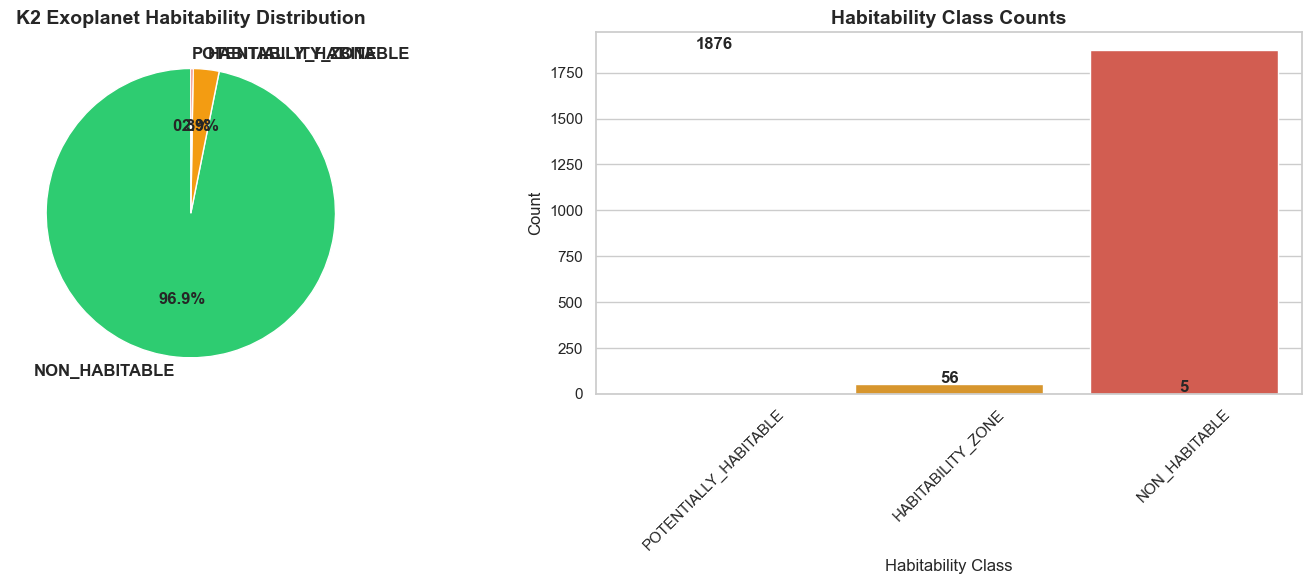


✅ Class distribution visualized!


In [7]:
print("="*60)
print("📊 HABITABILITY EDA")
print("="*60)

# 1. Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
colors = ['#2ECC71', '#F39C12', '#E74C3C']  # Green, Orange, Red
class_counts = df_clean['habitability_class'].value_counts()
axes[0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('K2 Exoplanet Habitability Distribution', fontsize=14, fontweight='bold')

# Bar plot
sns.countplot(data=df_clean, x='habitability_class', palette=colors, ax=axes[1],
              order=['POTENTIALLY_HABITABLE', 'HABITABILITY_ZONE', 'NON_HABITABLE'])
axes[1].set_title('Habitability Class Counts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Habitability Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Add count labels
for i, (cls, count) in enumerate(class_counts.items()):
    axes[1].text(i, count + 5, str(count), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n✅ Class distribution visualized!")


📈 Key Habitability Parameters by Class



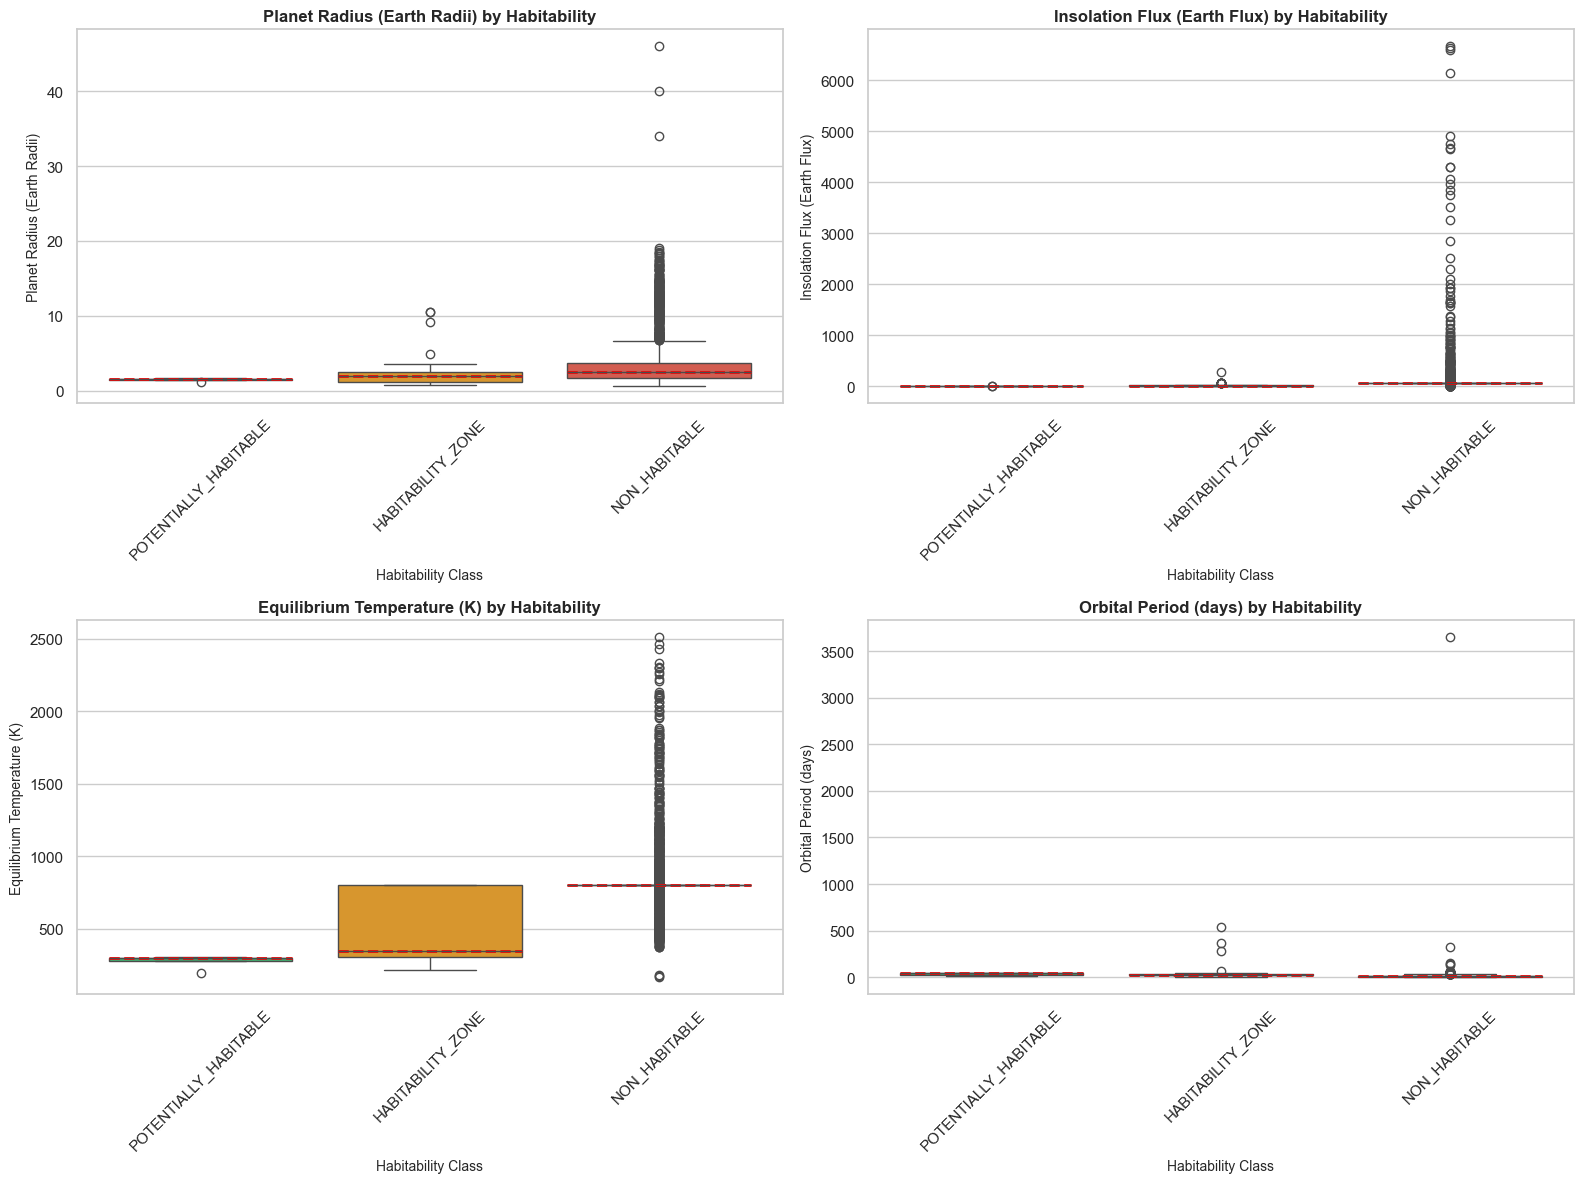

✅ Parameter distributions visualized!


In [8]:
# 2. Key habitability parameters by class
print("\n📈 Key Habitability Parameters by Class\n")

habitability_params = ['pl_rade', 'pl_insol', 'pl_eqt', 'pl_orbper', 'st_teff']
available_params = [p for p in habitability_params if p in df_clean.columns]

if len(available_params) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    param_labels = {
        'pl_rade': 'Planet Radius (Earth Radii)',
        'pl_insol': 'Insolation Flux (Earth Flux)',
        'pl_eqt': 'Equilibrium Temperature (K)',
        'pl_orbper': 'Orbital Period (days)',
        'st_teff': 'Stellar Temperature (K)'
    }
    
    for i, param in enumerate(available_params[:4]):
        ax = axes[i]
        
        # Box plot by habitability class
        order = ['POTENTIALLY_HABITABLE', 'HABITABILITY_ZONE', 'NON_HABITABLE']
        existing_order = [o for o in order if o in df_clean['habitability_class'].unique()]
        
        sns.boxplot(data=df_clean, x='habitability_class', y=param, 
                   palette=colors, ax=ax, order=existing_order)
        
        ax.set_title(f'{param_labels.get(param, param)} by Habitability', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Habitability Class', fontsize=10)
        ax.set_ylabel(param_labels.get(param, param), fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        
        # Add median lines
        for j, cls in enumerate(existing_order):
            median_val = df_clean[df_clean['habitability_class'] == cls][param].median()
            ax.hlines(median_val, j-0.4, j+0.4, colors='red', linestyle='--', linewidth=2)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Parameter distributions visualized!")
else:
    print("⚠️ Insufficient parameters available for visualization")

In [9]:
# 3. Statistical summary by habitability class
print("\n📊 Statistical Summary by Habitability Class\n")

for cls in ['POTENTIALLY_HABITABLE', 'HABITABILITY_ZONE', 'NON_HABITABLE']:
    if cls in df_clean['habitability_class'].values:
        print(f"\n{'='*60}")
        print(f"{cls}")
        print(f"{'='*60}")
        
        subset = df_clean[df_clean['habitability_class'] == cls]
        print(f"Count: {len(subset)} planets\n")
        
        summary_params = ['pl_rade', 'pl_insol', 'pl_eqt', 'pl_orbper', 'st_teff']
        available_summary = [p for p in summary_params if p in subset.columns]
        
        if available_summary:
            stats = subset[available_summary].describe().loc[['mean', '50%', 'std']].T
            stats.columns = ['Mean', 'Median', 'Std Dev']
            print(stats.round(3))


📊 Statistical Summary by Habitability Class


POTENTIALLY_HABITABLE
Count: 5 planets

               Mean    Median  Std Dev
pl_rade       1.487     1.510    0.226
pl_insol      1.300     1.500    0.599
pl_eqt      276.360   296.000   44.314
pl_orbper    34.522    44.556   14.634
st_teff    3847.200  3844.000  969.206

HABITABILITY_ZONE
Count: 56 planets

               Mean    Median  Std Dev
pl_rade       2.308     1.940    2.033
pl_insol     22.684     2.485   45.542
pl_eqt      505.063   348.910  245.678
pl_orbper    43.844    24.646   89.353
st_teff    3639.755  3541.500  816.719

NON_HABITABLE
Count: 1876 planets

               Mean    Median  Std Dev
pl_rade       3.877     2.466    3.901
pl_insol    149.421    69.700  486.444
pl_eqt      853.456   804.500  261.065
pl_orbper    12.528     7.754   85.006
st_teff    5149.359  5282.000  705.590


# 6. Feature Engineering

Create derived features specifically for habitability assessment.

In [10]:
print("="*60)
print("🔧 FEATURE ENGINEERING FOR HABITABILITY")
print("="*60)

df_features = df_clean.copy()

print("\n1️⃣ Creating derived habitability features...\n")

# 1. Earth Similarity Index components
if 'pl_rade' in df_features.columns:
    df_features['radius_similarity'] = 1 - abs(df_features['pl_rade'] - 1.0) / 10
    df_features['radius_similarity'] = df_features['radius_similarity'].clip(0, 1)
    print("   ✓ Created radius_similarity (1 = Earth-like)")

if 'pl_insol' in df_features.columns:
    df_features['insol_similarity'] = 1 - abs(df_features['pl_insol'] - 1.0) / 10
    df_features['insol_similarity'] = df_features['insol_similarity'].clip(0, 1)
    print("   ✓ Created insol_similarity (1 = Earth-like)")

if 'pl_eqt' in df_features.columns:
    # Earth's equilibrium temp is ~255K, but surface is ~288K
    df_features['temp_similarity'] = 1 - abs(df_features['pl_eqt'] - 255) / 500
    df_features['temp_similarity'] = df_features['temp_similarity'].clip(0, 1)
    print("   ✓ Created temp_similarity (1 = Earth-like)")

# 2. Habitability flags
if 'pl_insol' in df_features.columns:
    df_features['in_hz_conservative'] = ((df_features['pl_insol'] >= 0.25) & 
                                         (df_features['pl_insol'] <= 4.0)).astype(int)
    df_features['in_hz_optimistic'] = ((df_features['pl_insol'] >= 0.1) & 
                                       (df_features['pl_insol'] <= 10.0)).astype(int)
    print("   ✓ Created habitable zone flags")

if 'pl_rade' in df_features.columns:
    df_features['is_rocky'] = (df_features['pl_rade'] <= 2.0).astype(int)
    df_features['is_super_earth'] = ((df_features['pl_rade'] > 1.0) & 
                                     (df_features['pl_rade'] <= 2.0)).astype(int)
    df_features['is_earth_sized'] = ((df_features['pl_rade'] >= 0.8) & 
                                     (df_features['pl_rade'] <= 1.25)).astype(int)
    print("   ✓ Created planet type flags")

# 3. Logarithmic transformations
log_features = ['pl_orbper', 'pl_orbsmax', 'pl_insol']
for feat in log_features:
    if feat in df_features.columns:
        df_features[f'{feat}_log'] = np.log1p(df_features[feat])
        print(f"   ✓ Created {feat}_log")

# 4. Ratios and interactions
if 'pl_rade' in df_features.columns and 'st_rad' in df_features.columns:
    df_features['planet_star_radius_ratio'] = df_features['pl_rade'] / (df_features['st_rad'] * 109.2 + 1e-6)
    print("   ✓ Created planet_star_radius_ratio")

if 'pl_orbsmax' in df_features.columns and 'st_rad' in df_features.columns:
    # Distance in stellar radii
    df_features['orbit_stellar_radii'] = df_features['pl_orbsmax'] * 215.0 / df_features['st_rad']
    print("   ✓ Created orbit_stellar_radii")

# 5. Stellar classification
if 'st_teff' in df_features.columns:
    df_features['stellar_type'] = pd.cut(df_features['st_teff'],
                                         bins=[0, 3700, 5200, 6000, 7500, 50000],
                                         labels=['M', 'K', 'G', 'F', 'A_and_hotter'])
    print("   ✓ Created stellar_type categories")

print(f"\n✅ Feature engineering completed!")
print(f"📊 Features after engineering: {df_features.shape[1]} columns")
print("="*60)

🔧 FEATURE ENGINEERING FOR HABITABILITY

1️⃣ Creating derived habitability features...

   ✓ Created radius_similarity (1 = Earth-like)
   ✓ Created insol_similarity (1 = Earth-like)
   ✓ Created temp_similarity (1 = Earth-like)
   ✓ Created habitable zone flags
   ✓ Created planet type flags
   ✓ Created pl_orbper_log
   ✓ Created pl_orbsmax_log
   ✓ Created pl_insol_log
   ✓ Created planet_star_radius_ratio
   ✓ Created orbit_stellar_radii
   ✓ Created stellar_type categories

✅ Feature engineering completed!
📊 Features after engineering: 310 columns


# 7. Prepare ML-Ready Dataset

Select and scale features for machine learning models.

In [11]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle
import os

print("="*60)
print("🤖 PREPARING ML-READY DATASET")
print("="*60)

print("\n1️⃣ Selecting features for ML...\n")

# Numeric features for ML
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

# Exclude ID and target columns
exclude_cols = ['rowid', 'pl_name', 'hostname', 'k2_name', 'epic_hostname', 
                'hip_name', 'hd_name', 'tic_id', 'gaia_id', 'disposition',
                'sy_snum', 'sy_pnum', 'sy_mnum', 'disc_year']

ml_features = [f for f in numeric_cols if not any(ex in f for ex in exclude_cols)]

print(f"   Selected {len(ml_features)} numeric features for ML")
print(f"   Top features: {ml_features[:10]}")

# Handle infinite values
df_features[ml_features] = df_features[ml_features].replace([np.inf, -np.inf], np.nan)

# Final imputation
for col in ml_features:
    if df_features[col].isnull().sum() > 0:
        median_val = df_features[col].median()
        df_features[col].fillna(median_val, inplace=True)

print("\n   ✓ Cleaned infinite values and NaNs")

# Prepare X and y
X = df_features[ml_features].copy()
y = df_features['habitability_class'].copy()

print(f"\n2️⃣ Dataset shapes:")
print(f"   Feature matrix (X): {X.shape}")
print(f"   Target vector (y): {y.shape}")

# Encode target variable
print(f"\n3️⃣ Encoding target variable...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("   Class encoding:")
for i, class_name in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f"   {class_name} → {i} ({count} samples)")

# Feature scaling
print(f"\n4️⃣ Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
print("   ✓ Applied StandardScaler")

# Alternative scaling for tree models
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns, index=X.index)
print("   ✓ Applied MinMaxScaler (for tree models)")

# Train/val/test split
print(f"\n5️⃣ Splitting data...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled_df, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("   Split summary:")
print(f"   Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Testing: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification
print("\n   Class distribution verification:")
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = np.bincount(y_split) / len(y_split)
    print(f"   {split_name}: {[f'{d:.3f}' for d in dist]}")

print("\n✅ ML-ready dataset prepared!")
print("="*60)

🤖 PREPARING ML-READY DATASET

1️⃣ Selecting features for ML...

   Selected 270 numeric features for ML
   Top features: ['default_flag', 'cb_flag', 'rv_flag', 'pul_flag', 'ptv_flag', 'tran_flag', 'ast_flag', 'obm_flag', 'micro_flag', 'etv_flag']

   ✓ Cleaned infinite values and NaNs

2️⃣ Dataset shapes:
   Feature matrix (X): (1937, 270)
   Target vector (y): (1937,)

3️⃣ Encoding target variable...
   Class encoding:
   HABITABILITY_ZONE → 0 (56 samples)
   NON_HABITABLE → 1 (1876 samples)
   POTENTIALLY_HABITABLE → 2 (5 samples)

4️⃣ Scaling features...
   ✓ Applied StandardScaler
   ✓ Applied MinMaxScaler (for tree models)

5️⃣ Splitting data...
   Split summary:
   Training: 1162 samples (60.0%)
   Validation: 387 samples (20.0%)
   Testing: 388 samples (20.0%)

   Class distribution verification:
   Train: ['0.029', '0.968', '0.003']
   Val: ['0.028', '0.969', '0.003']
   Test: ['0.028', '0.969', '0.003']

✅ ML-ready dataset prepared!


# 8. Save Processed Data

Save the cleaned, classified, and ML-ready K2 habitability dataset.

In [12]:
print("="*60)
print("💾 SAVING K2 HABITABILITY DATASETS")
print("="*60)

# Create K2-specific directories
os.makedirs('../data/processed/k2', exist_ok=True)
os.makedirs('../artifacts/k2', exist_ok=True)

print("\n1️⃣ Saving train/validation/test splits...\n")

# Save StandardScaler splits
datasets = {
    'train': (X_train, y_train),
    'val': (X_val, y_val),
    'test': (X_test, y_test)
}

for split_name, (X_split, y_split) in datasets.items():
    split_df = X_split.copy()
    split_df['target'] = y_split
    split_df['target_name'] = le.inverse_transform(y_split)
    
    filepath = f'../data/processed/k2/k2_habitability_{split_name}.csv'
    split_df.to_csv(filepath, index=False)
    print(f"   ✓ Saved {filepath} ({split_df.shape[0]} rows)")

# Save MinMax splits for tree models
X_train_mm, X_temp_mm, y_train_mm, y_temp_mm = train_test_split(
    X_minmax_df, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)
X_val_mm, X_test_mm, y_val_mm, y_test_mm = train_test_split(
    X_temp_mm, y_temp_mm, test_size=0.5, random_state=42, stratify=y_temp_mm
)

datasets_mm = {
    'train_minmax': (X_train_mm, y_train_mm),
    'val_minmax': (X_val_mm, y_val_mm),
    'test_minmax': (X_test_mm, y_test_mm)
}

for split_name, (X_split, y_split) in datasets_mm.items():
    split_df = X_split.copy()
    split_df['target'] = y_split
    split_df['target_name'] = le.inverse_transform(y_split)
    
    filepath = f'../data/processed/k2/k2_habitability_{split_name}.csv'
    split_df.to_csv(filepath, index=False)
    print(f"   ✓ Saved {filepath}")

# Save full processed dataset
print(f"\n2️⃣ Saving full processed dataset...")
full_processed_path = '../data/processed/k2/k2_habitability_full_processed.csv'
df_features.to_csv(full_processed_path, index=False)
print(f"   ✓ Saved {full_processed_path} ({df_features.shape[0]} rows × {df_features.shape[1]} cols)")

# Save transformers
print(f"\n3️⃣ Saving ML artifacts...")

transformers = {
    'standard_scaler': scaler,
    'minmax_scaler': minmax_scaler,
    'label_encoder': le
}

for name, transformer in transformers.items():
    filepath = f'../artifacts/k2/k2_habitability_{name}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(transformer, f)
    print(f"   ✓ Saved {filepath}")

# Save metadata
metadata = {
    'dataset_name': 'K2 Exoplanet Habitability',
    'classification_type': 'habitability',
    'feature_names': ml_features,
    'n_features': len(ml_features),
    'target_classes': le.classes_.tolist(),
    'n_classes': len(le.classes_),
    'total_samples': len(df_features),
    'split_sizes': {
        'train': len(X_train),
        'val': len(X_val),
        'test': len(X_test)
    },
    'class_distribution': df_features['habitability_class'].value_counts().to_dict()
}

metadata_path = '../artifacts/k2/k2_habitability_metadata.pkl'
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"   ✓ Saved {metadata_path}")

print("\n" + "="*60)
print("✅ ALL K2 HABITABILITY DATASETS SAVED SUCCESSFULLY!")
print("="*60)

print("\n📁 Generated files:")
print("   📊 ../data/processed/k2/k2_habitability_train.csv")
print("   📊 ../data/processed/k2/k2_habitability_val.csv")
print("   📊 ../data/processed/k2/k2_habitability_test.csv")
print("   📊 ../data/processed/k2/k2_habitability_*_minmax.csv")
print("   📊 ../data/processed/k2/k2_habitability_full_processed.csv")
print("   🔧 ../artifacts/k2/k2_habitability_standard_scaler.pkl")
print("   🔧 ../artifacts/k2/k2_habitability_minmax_scaler.pkl")
print("   🔧 ../artifacts/k2/k2_habitability_label_encoder.pkl")
print("   🔧 ../artifacts/k2/k2_habitability_metadata.pkl")

💾 SAVING K2 HABITABILITY DATASETS

1️⃣ Saving train/validation/test splits...

   ✓ Saved ../data/processed/k2/k2_habitability_train.csv (1162 rows)
   ✓ Saved ../data/processed/k2/k2_habitability_val.csv (387 rows)
   ✓ Saved ../data/processed/k2/k2_habitability_test.csv (388 rows)
   ✓ Saved ../data/processed/k2/k2_habitability_train_minmax.csv
   ✓ Saved ../data/processed/k2/k2_habitability_val_minmax.csv
   ✓ Saved ../data/processed/k2/k2_habitability_test_minmax.csv

2️⃣ Saving full processed dataset...
   ✓ Saved ../data/processed/k2/k2_habitability_full_processed.csv (1937 rows × 310 cols)

3️⃣ Saving ML artifacts...
   ✓ Saved ../artifacts/k2/k2_habitability_standard_scaler.pkl
   ✓ Saved ../artifacts/k2/k2_habitability_minmax_scaler.pkl
   ✓ Saved ../artifacts/k2/k2_habitability_label_encoder.pkl
   ✓ Saved ../artifacts/k2/k2_habitability_metadata.pkl

✅ ALL K2 HABITABILITY DATASETS SAVED SUCCESSFULLY!

📁 Generated files:
   📊 ../data/processed/k2/k2_habitability_train.csv
   

# 9. Final Summary & Next Steps

Summary of K2 habitability processing and recommendations for ML phase.

In [13]:
print("="*60)
print("🌍 K2 EXOPLANET HABITABILITY - FINAL SUMMARY")
print("="*60)

print("\n📊 DATASET STATISTICS")
print("-"*60)
print(f"Original dataset: {initial_shape[0]} rows × {initial_shape[1]} columns")
print(f"Processed dataset: {df_features.shape[0]} rows × {df_features.shape[1]} columns")
print(f"Data reduction: {((initial_shape[0] - df_features.shape[0])/initial_shape[0]*100):.1f}% rows removed")
print(f"Feature expansion: {df_features.shape[1] - initial_shape[1]} new features created")

print("\n🎯 HABITABILITY CLASSIFICATION RESULTS")
print("-"*60)
final_dist = df_features['habitability_class'].value_counts()
for cls, count in final_dist.items():
    pct = (count / len(df_features)) * 100
    print(f"{cls}: {count} planets ({pct:.2f}%)")

print("\n🔧 FEATURE ENGINEERING SUMMARY")
print("-"*60)
print(f"Total ML features: {len(ml_features)}")
print("Key habitability features created:")
print("  • Earth similarity indices (radius, insolation, temperature)")
print("  • Habitable zone flags (conservative & optimistic)")
print("  • Planet type flags (rocky, super-Earth, Earth-sized)")
print("  • Logarithmic transformations for skewed features")
print("  • Stellar classification (M, K, G, F, A stars)")

print("\n💾 OUTPUT FILES")
print("-"*60)
print("Ready for Machine Learning:")
print("  ✓ Train/Val/Test splits (StandardScaler)")
print("  ✓ Train/Val/Test splits (MinMaxScaler for tree models)")
print("  ✓ Full processed dataset with all features")
print("  ✓ Scalers and encoders for new data")
print("  ✓ Metadata with feature information")

print("\n🤖 RECOMMENDED ML APPROACHES")
print("-"*60)
print("1. Random Forest / XGBoost (use MinMax scaled data)")
print("   - Good for handling class imbalance")
print("   - Feature importance analysis")
print("   - Non-linear relationships")

print("\n2. Gradient Boosting (use MinMax scaled data)")
print("   - Excellent for rare class detection (POTENTIALLY_HABITABLE)")
print("   - Hyperparameter tuning crucial")

print("\n3. Neural Networks (use Standard scaled data)")
print("   - Deep learning for complex patterns")
print("   - May need class weighting")

print("\n4. Ensemble Methods")
print("   - Combine predictions from multiple models")
print("   - Voting or stacking classifiers")

print("\n⚖️ CLASS IMBALANCE CONSIDERATIONS")
print("-"*60)
min_ratio = final_dist.min() / final_dist.max()
print(f"Class balance ratio: {min_ratio:.3f}")
if min_ratio < 0.3:
    print("⚠️ Significant imbalance detected!")
    print("Recommendations:")
    print("  • Use SMOTE for oversampling minority class")
    print("  • Apply class weights in model training")
    print("  • Focus on precision/recall for POTENTIALLY_HABITABLE")
    print("  • Use stratified k-fold cross-validation")
else:
    print("✅ Classes reasonably balanced")

print("\n📈 EVALUATION METRICS")
print("-"*60)
print("Primary metrics:")
print("  • F1-Score (weighted & per-class)")
print("  • Precision & Recall (especially for POTENTIALLY_HABITABLE)")
print("  • Confusion Matrix")
print("  • ROC-AUC (One-vs-Rest)")

print("\n🔍 NEXT STEPS")
print("-"*60)
print("1. Process Kepler dataset (02_kepler_habitability.ipynb)")
print("2. Process TESS TOI dataset (03_tess_toi_habitability.ipynb)")
print("3. Compare habitability distributions across missions")
print("4. Develop ML models for each mission")
print("5. Create ensemble predictions combining all missions")
print("6. Validate on test sets and generate final habitability catalog")

print("\n" + "="*60)
print("✅ K2 HABITABILITY PROCESSING COMPLETE!")
print("🚀 Ready for Machine Learning Phase!")
print("="*60)

🌍 K2 EXOPLANET HABITABILITY - FINAL SUMMARY

📊 DATASET STATISTICS
------------------------------------------------------------
Original dataset: 3992 rows × 295 columns
Processed dataset: 1937 rows × 310 columns
Data reduction: 51.5% rows removed
Feature expansion: 15 new features created

🎯 HABITABILITY CLASSIFICATION RESULTS
------------------------------------------------------------
NON_HABITABLE: 1876 planets (96.85%)
HABITABILITY_ZONE: 56 planets (2.89%)
POTENTIALLY_HABITABLE: 5 planets (0.26%)

🔧 FEATURE ENGINEERING SUMMARY
------------------------------------------------------------
Total ML features: 270
Key habitability features created:
  • Earth similarity indices (radius, insolation, temperature)
  • Habitable zone flags (conservative & optimistic)
  • Planet type flags (rocky, super-Earth, Earth-sized)
  • Logarithmic transformations for skewed features
  • Stellar classification (M, K, G, F, A stars)

💾 OUTPUT FILES
-------------------------------------------------------